# Introduction to PyTorch (Part 2)


**Weight Initialization Methods in Deep Learning**

| **Method** | **Description** | **Mathematical Basis** | **When to Use** | **Points to Remember (Interview Focus)** | **PyTorch Implementation** |
|---|---|---|---|---|---|
| **Zero Initialization** | All weights are initialized to 0. |  `w = 0` for all weights `w` | **Almost never.**  Only for specific, very rare cases where symmetry breaking isn't needed (and you know what you're doing). | - **Major Problem:** Leads to symmetry. All neurons in a layer will learn the same thing, making the network no better than a single neuron. The gradients will be the same for all weights, preventing effective learning.  - **Avoid in almost all cases.** | `nn.init.zeros_(tensor)` |
| **Constant Initialization** | All weights initialized to the same constant value. | `w = c` (where `c` is a constant) |  -  Rarely used for weights. -  Sometimes used for initializing **bias** terms (often to 0 or a small positive value). | - Similar symmetry problems to zero initialization if used for weights.  - Can be useful for biases to ensure neurons initially have a non-zero output. | `nn.init.constant_(tensor, value)` |
| **Random Initialization (Uniform)** | Weights are drawn from a uniform distribution within a specified range. |  `w ~ U(a, b)` (Uniform distribution between `a` and `b`) | - General-purpose initialization, but often outperformed by Xavier/Glorot or He/Kaiming. - Can be used when you have a specific reason to believe a uniform distribution is appropriate. | - The range `[a, b]` is crucial.  Too large a range can lead to exploding gradients; too small can lead to vanishing gradients. - Less common now that Xavier/He are widely available. | `nn.init.uniform_(tensor, a, b)` |
| **Random Initialization (Normal)** | Weights are drawn from a normal (Gaussian) distribution. | `w ~ N(μ, σ^2)` (Normal distribution with mean `μ` and variance `σ^2`) | - Another general-purpose method, but again, often Xavier/He are better. - Can be used if you have a specific reason for a normal distribution. | - Usually, the mean `μ` is set to 0.  The standard deviation `σ` is important.  Too large a `σ` leads to exploding gradients; too small leads to vanishing gradients. | `nn.init.normal_(tensor, mean, std)` |
| **Xavier/Glorot Initialization (Uniform)** | Weights drawn from a uniform distribution, with the range scaled based on the number of input and output neurons. |  $$ `w ~ U(-√(6/(fan_in + fan_out)), √(6/(fan_in + fan_out)))` $$  where `fan_in` is the number of input units and `fan_out` is the number of output units. | - **Good default choice for networks using sigmoid or tanh activation functions.** - `Designed to keep the variance of activations consistent across layers during the forward and backward passes.` | - Addresses the vanishing/exploding gradient problem. - Aims to maintain signal propagation. - Works well with activations that are symmetric around 0 and have a linear region near 0. | `nn.init.xavier_uniform_(tensor, gain=1.0)` |
| **Xavier/Glorot Initialization (Normal)** | Weights drawn from a normal distribution, with the standard deviation scaled based on the number of input and output neurons. | `w ~ N(0, √(2/(fan_in + fan_out)))` | - **Also a good default choice for sigmoid/tanh activations.** - Similar goals to Xavier/Glorot uniform. | - The normal distribution version is sometimes preferred for theoretical reasons.  In practice, the uniform and normal versions often perform similarly. | `nn.init.xavier_normal_(tensor, gain=1.0)` |
| **He/Kaiming Initialization (Uniform)** | Weights drawn from a uniform distribution, with the range scaled based on the number of *input* neurons. | `w ~ U(-√(6/fan_in), √(6/fan_in))` | - **Good default choice for networks using ReLU (Rectified Linear Unit) activation functions and its variants (LeakyReLU, ELU, etc.).** | - Specifically designed to address the issues that arise with ReLUs, which can "die" (output 0) and stop learning. - Focuses on the forward pass variance. | `nn.init.kaiming_uniform_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')` |
| **He/Kaiming Initialization (Normal)** | Weights drawn from a normal distribution, with the standard deviation scaled based on the number of *input* neurons. | `w ~ N(0, √(2/fan_in))` | - **Also a good default for ReLU activations.** | - Similar goals to He/Kaiming uniform. The normal distribution version is sometimes preferred. | `nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')` |
| **Orthogonal Initialization** | Weights are initialized as an orthogonal matrix. |  The weight matrix `W` satisfies `W^T * W = I` (where `I` is the identity matrix). | -  Primarily used in **recurrent neural networks (RNNs)** to mitigate vanishing and exploding gradients.  - Can also be used in other contexts where preserving the norm of the input is important. | - Helps maintain the norm of the hidden state across time steps in RNNs.  - Can improve training stability. | `nn.init.orthogonal_(tensor, gain=1.0)` |
| **Sparse Initialization** |  A fraction of the weights are set to zero, creating a sparse weight matrix. |  Each weight has a probability `p` of being set to zero. | -  Can be used to encourage sparsity in the network. -  Sometimes used in combination with other initialization methods. |  - Can help with regularization and reduce the number of parameters. | `nn.init.sparse_(tensor, sparsity, std=0.01)` |
| **LSUV (Layer-sequential Unit-variance)** | Iterative procedure.  1. Initialize weights (usually with orthogonal initialization). 2. Forward pass a mini-batch. 3. Adjust the weights of each layer to have unit variance. 4. Repeat steps 2-3 until convergence. | Aims for unit variance of activations in each layer. | -  Used when you want to ensure good signal propagation, especially in very deep networks. | -  More complex than other methods; requires a forward pass during initialization. -  Can be very effective but is less commonly used than Xavier/He. | *Not directly available as a single function in `nn.init`*. Requires a custom implementation. |

**Key Concepts and Interview Tips:**

*   **Vanishing/Exploding Gradients:**  The core problem that good initialization methods address.
    *   **Vanishing:** Gradients become very small during backpropagation, making learning extremely slow or impossible.
    *   **Exploding:** Gradients become very large, leading to unstable training and potentially NaN values.
*   **Symmetry Breaking:**  Initialization should break symmetry; otherwise, neurons in a layer will learn the same thing. Random initialization (uniform or normal) achieves this.
*   **Activation Functions:**  The choice of initialization method is closely tied to the activation function used in the network.
    *   **Sigmoid/Tanh:**  Xavier/Glorot is generally preferred.
    *   **ReLU and variants:** He/Kaiming is generally preferred.
*   **`fan_in` and `fan_out`:**
    *   **`fan_in`:** The number of input units to a neuron (or layer).
    *   **`fan_out`:** The number of output units from a neuron (or layer).
*   **`nn.init`:**  The PyTorch module that provides these initialization functions.  You typically use them like this:
    ```python
    import torch.nn as nn

    linear_layer = nn.Linear(100, 50)
    nn.init.xavier_uniform_(linear_layer.weight)  # Initialize weights
    nn.init.zeros_(linear_layer.bias)           # Initialize biases (often to 0)
    ```
*   **`nn.Parameter`:** Remember that weights and biases in PyTorch should be wrapped in `nn.Parameter` so that they are tracked by the optimizer.  The initialization functions work directly on the underlying tensor data.
* **gain** Some initialization function have gain. It is used to scale up or down the initialization.



Here’s a **more readable and interactive representation** of your loss function guide while keeping all the original text intact. Instead of a long table, I’ve structured it into **sections with bullet points**, making it easier to scan and compare.

---

# **Loss Functions in `torch.nn` for Deep Learning and LLMs**

## **1️⃣ Classification (Multi-Class)**
### 🔹 `nn.CrossEntropyLoss(weight=None, ignore_index=-100, reduction='mean')`
- **Description:** Computes cross-entropy loss between input logits and target labels.  
  - Internally combines `LogSoftmax` and `NLLLoss` for numerical stability.  
- **Formula:** `-sum(y_i * log(p_i))`, where `y_i` is the true label (one-hot encoded) and `p_i` is the predicted probability.  
- **Use When:**
  - Multi-class classification problems (more than 2 classes).  
  - Model output is **raw logits** (before softmax).  
- **Key Parameters:**
  - `weight`: Adjusts class weights (useful for imbalanced datasets).  
  - `ignore_index`: Ignores a specific class index (e.g., padding tokens in NLP).  
  - `reduction`: `'none'`, `'mean'`, `'sum'` (default is `'mean'`).  
- **Interview Tips:**
  - ✅ **Do NOT apply softmax** before using `CrossEntropyLoss`.  
  - ✅ Measures the difference between predicted & true probability distributions.  
  - ✅ Explain why it’s **better than manually applying `LogSoftmax` + `NLLLoss`**.  
- **Example:**
  ```python
  loss_fn = nn.CrossEntropyLoss()
  loss = loss_fn(logits, labels)  # logits: (batch_size, num_classes), labels: (batch_size)
  ```

---

### 🔹 `nn.NLLLoss(weight=None, ignore_index=-100, reduction='mean')`
- **Description:** Negative log-likelihood loss (assumes input is already log probabilities).  
- **Formula:** `-sum(y_i * log_p_i)`, where `log_p_i` is log of predicted probability.  
- **Use When:**
  - You’ve **already applied `LogSoftmax`** to your model's output.  
- **Key Parameters:** Same as `CrossEntropyLoss`.  
- **Interview Tips:**
  - ✅ Unlike `CrossEntropyLoss`, expects **log probabilities**, not raw logits.  
  - ✅ Less common because `CrossEntropyLoss` is **more stable & convenient**.  
- **Example:**
  ```python
  log_probs = nn.LogSoftmax(dim=1)(logits)
  loss_fn = nn.NLLLoss()
  loss = loss_fn(log_probs, labels)
  ```

---

## **2️⃣ Classification (Binary)**
### 🔹 `nn.BCELoss(weight=None, reduction='mean')`
- **Description:** Binary cross-entropy loss for **binary classification**.  
- **Formula:** `- (y * log(p) + (1 - y) * log(1 - p))`  
- **Use When:**
  - Binary classification problems (2 classes).  
  - **Requires probabilities** as input (use `Sigmoid` before this).  
- **Key Parameters:** 
  - `weight`: Adjusts class weights.  
  - `reduction`: `'none'`, `'mean'`, `'sum'`.  
- **Interview Tips:**
  - ❌ **Don’t use raw logits** → apply `Sigmoid` first.  
  - ❌ **Less numerically stable** than `BCEWithLogitsLoss`.  
- **Example:**
  ```python
  probabilities = nn.Sigmoid()(logits)
  loss_fn = nn.BCELoss()
  loss = loss_fn(probabilities, labels)
  ```

---

### 🔹 `nn.BCEWithLogitsLoss(weight=None, reduction='mean', pos_weight=None)`
- **Description:** **Numerically stable** version of `BCELoss`.  
- **Formula:** Same as `BCELoss`, but **applies `Sigmoid` internally**.  
- **Use When:**
  - Binary classification (preferred over `BCELoss`).  
  - **Use directly with raw logits** (no need for `Sigmoid`).  
- **Key Parameters:**
  - `pos_weight`: Handles imbalanced datasets by weighting positive class.  
- **Interview Tips:**
  - ✅ **More stable** than `BCELoss`.  
  - ✅ Works **directly on logits**, unlike `BCELoss`.  
- **Example:**
  ```python
  loss_fn = nn.BCEWithLogitsLoss()
  loss = loss_fn(logits, labels)
  ```

---

## **3️⃣ Regression**
### 🔹 `nn.MSELoss(reduction='mean')` (Mean Squared Error)
- **Formula:** `(1/n) * sum((y_i - p_i)^2)`  
- **Use When:** Predicting **continuous values**.  
- **Interview Tips:**  
  - ❌ **Sensitive to outliers** due to squaring.  
- **Example:**
  ```python
  loss_fn = nn.MSELoss()
  loss = loss_fn(predictions, targets)
  ```

---

### 🔹 `nn.L1Loss(reduction='mean')` (Mean Absolute Error)
- **Formula:** `(1/n) * sum(|y_i - p_i|)`  
- **Use When:**  
  - Regression tasks requiring **robustness to outliers**.  
- **Interview Tips:**  
  - ✅ **Less sensitive to outliers** than MSE.  
- **Example:**
  ```python
  loss_fn = nn.L1Loss()
  loss = loss_fn(predictions, targets)
  ```

---

### 🔹 `nn.SmoothL1Loss(reduction='mean', beta=1.0)` (Huber Loss)
- **Formula:** Uses **MSE** for small errors, **L1** for large errors.  
- **Use When:** Regression tasks needing **a balance between MSE & L1**.  
- **Key Parameter:** `beta` (controls transition point).  
- **Interview Tips:**  
  - ✅ **More robust** than MSE, but still differentiable.  
- **Example:**
  ```python
  loss_fn = nn.SmoothL1Loss()
  loss = loss_fn(predictions, targets)
  ```

---

## **4️⃣ Other Losses**
### 🔹 `nn.KLDivLoss(reduction='mean', log_target=False)`
- **Description:** Measures **difference between two probability distributions**.  
- **Formula:** `KL(p || q) = sum(p_i * log(p_i / q_i))`  
- **Use When:**  
  - **Knowledge distillation**, variational autoencoders (VAEs), etc.  
- **Interview Tips:**  
  - ✅ **Asymmetric** (`KL(p || q) != KL(q || p)`).  
- **Example:**
  ```python
  loss_fn = nn.KLDivLoss()
  loss = loss_fn(log_probs, target_probs)
  ```

---

### 🔹 `nn.MarginRankingLoss(margin=0.0, reduction='mean')`
- **Formula:** `max(0,−y∗(x1−x2)+margin)`  
- **Use When:** Learning **relative distance** between samples.  
- **Example:**
  ```python
  loss_fn = nn.MarginRankingLoss()
  loss = loss_fn(x1, x2, y)
  ```

---

### 🔹 `nn.TripletMarginLoss(margin=1.0, p=2.0, reduction='mean')`
- **Formula:** `max{d(a, p) − d(a, n) + margin, 0}`  
- **Use When:** Learning **relative similarity** (e.g., face recognition).  
- **Example:**
  ```python
  loss_fn = nn.TripletMarginLoss()
  loss = loss_fn(anchor, positive, negative)
  ```

---

### 🔹 `nn.CTCLoss(blank=0, reduction='mean', zero_infinity=False)`
- **Description:** Loss for **speech recognition & OCR**.  
- **Use When:** **Alignments are unknown** between input & output sequences.  
- **Interview Tips:**  
  - ✅ Understand **CTC blank token**.  
- **Example:**
  ```python
  loss_fn = nn.CTCLoss()
  loss = loss_fn(log_probs, targets, input_lengths, target_lengths)
  ```

---

This format makes it **easier to scan, compare, and retain key concepts**! 🚀


# <span style="color:#1E90FF; font-size:1.5em;">**Interactive Guide: Common `torch.nn` Modules for Deep Learning & LLMs**</span> 🚀

Explore each section below, where you'll find the module’s description, usage in LLMs/DL, key parameters, interview focus points, and runnable code examples. Enjoy the colorful journey! 🎉

---

## <span style="color:#FF4500; font-size:1.2em;">**Linear Layers 🔥**</span>

### `nn.Linear(in_features, out_features, bias=True)`

- **Description:**  
  Fully connected layer. Performs a linear transformation: `y = xW^T + b`  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Fundamental building block for many networks!</span>

- **When to Use (LLM/DL Specific):**
  - The foundation of many neural networks.
  - Used in MLPs (Multilayer Perceptrons).
  - Output layers for classification/regression.
  - Dense layers within complex architectures.
  - Projecting embeddings to a different dimension.
  - Final layer before a softmax for classification.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`in_features`</span>: Number of input features.
  - <span style="color:#8A2BE2;">`out_features`</span>: Number of output features.
  - <span style="color:#8A2BE2;">`bias`</span>: Whether to include a bias term (usually True).
  - <span style="color:#8A2BE2;">`.weight`</span>: The weight matrix (an `nn.Parameter`).
  - <span style="color:#8A2BE2;">`.bias`</span>: The bias vector (an `nn.Parameter`).

- **Points to Remember (Interview Focus):**
  - Understand the linear transformation formula.
  - Explain how input/output dimensions relate to `in_features` and `out_features`.
  - Weight initialization (e.g., Xavier/He) is crucial.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a linear layer
  linear = nn.Linear(128, 64)
  input_tensor = torch.randn(32, 128)  # Batch size 32, 128 features
  output = linear(input_tensor)
  print(output.shape)  # Expected output: [32, 64]
  ```

---

## <span style="color:#FF8C00; font-size:1.2em;">**Convolutional Layers 📸**</span>

### `nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True)`

- **Description:**  
  2D convolution used primarily for image processing (also adaptable for 1D sequences).  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Think of it as a sliding window for extracting features!</span>

- **When to Use (LLM/DL Specific):**
  - Feature extraction from images.
  - Building convolutional neural networks (CNNs).
  - Adapting for text processing (treat text as a 1D "image").

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`in_channels`</span>: Number of input channels (e.g., 3 for RGB images).
  - <span style="color:#8A2BE2;">`out_channels`</span>: Number of filters.
  - <span style="color:#8A2BE2;">`kernel_size`</span>: Size of the convolution kernel.
  - Additional parameters: `stride`, `padding`, `dilation`, `groups`, `bias`.

- **Points to Remember (Interview Focus):**
  - How the sliding window mechanism works.
  - Effect of `kernel_size`, `stride`, and `padding` on the output size.
  - Differences among 1D, 2D, and 3D convolutions.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a 2D convolution layer
  conv = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
  image_tensor = torch.randn(8, 3, 32, 32)  # Batch size 8, 3 channels, 32x32 image
  output = conv(image_tensor)
  print(output.shape)  # Expected output: [8, 16, 32, 32]
  ```

---

## <span style="color:#8A2BE2; font-size:1.2em;">**Recurrent Layers ⏱️**</span>

### `nn.RNN(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0, bidirectional=False)`

- **Description:**  
  Basic RNN layer for sequential data.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Modern tasks often favor LSTM/GRU due to gradient challenges.</span>

- **When to Use (LLM/DL Specific):**
  - Processing sequential data (text, time series).
  - **Rarely used directly now** because of vanishing/exploding gradient issues.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`input_size`</span>: Number of input features.
  - <span style="color:#8A2BE2;">`hidden_size`</span>: Number of features in the hidden state.
  - <span style="color:#8A2BE2;">`num_layers`</span>, <span style="color:#8A2BE2;">`bias`</span>, <span style="color:#8A2BE2;">`batch_first`</span>, <span style="color:#8A2BE2;">`dropout`</span>, <span style="color:#8A2BE2;">`bidirectional`</span>.

- **Points to Remember (Interview Focus):**
  - Basic RNN cell structure.
  - Its limitations due to gradient issues.
  - Why LSTMs/GRUs are preferred for most sequence tasks.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a basic RNN layer
  rnn = nn.RNN(10, 20, num_layers=2, batch_first=True)
  input_tensor = torch.randn(5, 7, 10)  # Batch size 5, sequence length 7, 10 features
  output, hidden = rnn(input_tensor)
  print(output.shape)  # Expected shape: [5, 7, 20]
  ```

---

### `nn.LSTM(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0, bidirectional=False)`

- **Description:**  
  LSTM layer for advanced sequence processing.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: The workhorse for many NLP tasks!</span>

- **When to Use (LLM/DL Specific):**
  - Language modeling, machine translation, text classification.
  - Mitigates vanishing gradients better than basic RNNs.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - Uses same parameters as `nn.RNN` plus detailed weight and bias parameters (e.g., <span style="color:#8A2BE2;">`.weight_ih_l[k]`</span>, <span style="color:#8A2BE2;">`.bias_ih_l[k]`</span>).

- **Points to Remember (Interview Focus):**
  - Structure of LSTM cells (input, forget, output gates, cell state).
  - How gates control the flow of information.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define an LSTM layer
  lstm = nn.LSTM(10, 20, num_layers=2, batch_first=True)
  input_sequence = torch.randn(5, 7, 10)  # Batch size 5, sequence length 7, 10 features
  output, (hidden, cell) = lstm(input_sequence)
  print(output.shape)  # Expected output: [5, 7, 20]
  ```

---

### `nn.GRU(input_size, hidden_size, num_layers=1, bias=True, batch_first=False, dropout=0, bidirectional=False)`

- **Description:**  
  GRU layer with a simpler design than LSTM.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: A streamlined alternative for sequence tasks!</span>

- **When to Use (LLM/DL Specific):**
  - Similar to LSTMs, but with fewer gates.
  - Often chosen for efficiency in sequence processing.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - Same as those in `nn.RNN` and `nn.LSTM` (e.g., <span style="color:#8A2BE2;">`input_size`</span>, <span style="color:#8A2BE2;">`hidden_size`</span>, etc.).

- **Points to Remember (Interview Focus):**
  - Understand GRU's simpler structure.
  - Compare GRU and LSTM in terms of speed and performance.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a GRU layer
  gru = nn.GRU(10, 20, num_layers=2, batch_first=True)
  input_tensor = torch.randn(5, 7, 10)  # Batch size 5, sequence length 7, 10 features
  output, hidden = gru(input_tensor)
  print(output.shape)  # Expected output: [5, 7, 20]
  ```

---

## <span style="color:#FF1493; font-size:1.2em;">**Embeddings 💬**</span>

### `nn.Embedding(num_embeddings, embedding_dim, padding_idx=None, ...)`

- **Description:**  
  Maps integer indices (e.g., word tokens) to dense vectors.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Essential for representing tokens in NLP models!</span>

- **When to Use (LLM/DL Specific):**
  - Representing words and discrete tokens.
  - Useful for categorical features in various domains.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`num_embeddings`</span>: Vocabulary size.
  - <span style="color:#8A2BE2;">`embedding_dim`</span>: Dimensionality of embeddings.
  - <span style="color:#8A2BE2;">`padding_idx`</span>: Optional index for padding (outputs zeros).
  - <span style="color:#8A2BE2;">`.weight`</span>: The embedding matrix.

- **Points to Remember (Interview Focus):**
  - Embeddings are learned representations.
  - Know how to perform token lookup using `nn.Embedding`.
  - Benefits: Dense representations that capture semantic relationships.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define an embedding layer
  vocab_size = 10000
  embedding_dim = 300
  embedding = nn.Embedding(vocab_size, embedding_dim)
  token_ids = torch.randint(0, vocab_size, (32, 15))  # Batch size 32, sequence length 15
  embedded_sequence = embedding(token_ids)
  print(embedded_sequence.shape)  # Expected output: [32, 15, 300]
  ```

---

## <span style="color:#20B2AA; font-size:1.2em;">**Activation Functions ⚡**</span>

### `nn.ReLU(inplace=False)`

- **Description:**  
  Rectified Linear Unit: `f(x) = max(0, x)`  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: The most popular activation for hidden layers!</span>

- **When to Use (LLM/DL Specific):**
  - Efficient and helps mitigate vanishing gradients.
  - Common in many network architectures.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`inplace`</span>: If True, performs the operation in-place (saves memory).

- **Points to Remember (Interview Focus):**
  - Know the ReLU formula and its behavior.
  - Be aware of the "dying ReLU" problem.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a ReLU activation
  relu = nn.ReLU()
  input_tensor = torch.randn(5, 10)
  activated_tensor = relu(input_tensor)
  print(activated_tensor)
  ```

---

### `nn.LeakyReLU(negative_slope=0.01, inplace=False)`

- **Description:**  
  Leaky ReLU: `f(x) = x if x > 0 else negative_slope * x`  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Prevents neurons from "dying" by allowing a small gradient for negative inputs.</span>

- **When to Use (LLM/DL Specific):**
  - Use as an alternative to ReLU for better gradient flow.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`negative_slope`</span>: Controls the slope for negative values.

- **Points to Remember (Interview Focus):**
  - Know the difference between ReLU and LeakyReLU.
  - Understand how it helps maintain gradient flow.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a LeakyReLU activation
  leaky_relu = nn.LeakyReLU(negative_slope=0.2)
  input_tensor = torch.randn(5, 10)
  activated_tensor = leaky_relu(input_tensor)
  print(activated_tensor)
  ```

---

### `nn.Sigmoid()`

- **Description:**  
  Sigmoid function: `f(x) = 1 / (1 + exp(-x))`  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Ideal for binary outputs, but beware of vanishing gradients!</span>

- **When to Use (LLM/DL Specific):**
  - Squashes values to (0, 1); common in binary classification outputs.
  - Typically replaced in hidden layers by ReLU variants.

- **Points to Remember (Interview Focus):**
  - Know the sigmoid formula and its limitations.
  - Understand issues with non-zero-centered outputs and gradient vanishing.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a Sigmoid activation
  sigmoid = nn.Sigmoid()
  input_tensor = torch.randn(5, 10)
  output = sigmoid(input_tensor)
  print(output)
  ```

---

### `nn.Tanh()`

- **Description:**  
  Hyperbolic tangent: `f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))`  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Zero-centered, but can also suffer from vanishing gradients.</span>

- **When to Use (LLM/DL Specific):**
  - Squashes values to (-1, 1) and is zero-centered.
  - Often replaced by ReLU variants in deeper networks.

- **Points to Remember (Interview Focus):**
  - Know the tanh formula and its characteristics.
  - Understand its benefits and limitations compared to sigmoid.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a Tanh activation
  tanh = nn.Tanh()
  input_tensor = torch.randn(5, 10)
  output = tanh(input_tensor)
  print(output)
  ```

---

### `nn.Softmax(dim=None)`

- **Description:**  
  Softmax function that converts a vector of values into a probability distribution.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Crucial for multi-class classification outputs!</span>

- **When to Use (LLM/DL Specific):**
  - Ensures outputs sum to 1 for probability interpretation.
  - Typically paired with `nn.CrossEntropyLoss`.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`dim`</span>: Dimension along which softmax is computed.

- **Points to Remember (Interview Focus):**
  - Understand how softmax converts logits to probabilities.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a Softmax activation
  softmax = nn.Softmax(dim=1)
  logits = torch.randn(5, 10)  # 5 samples, 10 classes
  probabilities = softmax(logits)
  print(probabilities)
  ```

---

## <span style="color:#DA70D6; font-size:1.2em;">**Normalization Layers 🧹**</span>

### `nn.BatchNorm1d(num_features, ...)` / `nn.BatchNorm2d(num_features, ...)`

- **Description:**  
  Batch Normalization normalizes activations within a mini-batch.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Accelerates training and stabilizes deep networks!</span>

- **When to Use (LLM/DL Specific):**
  - Improve training speed and stability.
  - Reduce internal covariate shift.
  - Crucial for very deep networks.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`num_features`</span>: For 1D features or 2D channels.
  - Running statistics: <span style="color:#8A2BE2;">`.running_mean`</span>, <span style="color:#8A2BE2;">`.running_var`</span>.
  - Learnable parameters: <span style="color:#8A2BE2;">`.weight`</span> and <span style="color:#8A2BE2;">`.bias`</span>.

- **Points to Remember (Interview Focus):**
  - Understand batch normalization’s impact on training dynamics.
  - Know its behavior difference during training (`model.train()`) and inference (`model.eval()`).

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a BatchNorm1d layer
  bn = nn.BatchNorm1d(128)
  input_tensor = torch.randn(32, 128)  # Batch size 32, 128 features
  normalized_tensor = bn(input_tensor)
  print(normalized_tensor.shape)  # Expected output: [32, 128]
  ```

---

### `nn.LayerNorm(normalized_shape, ...)`

- **Description:**  
  Layer Normalization normalizes across features for each sample.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Widely used in Transformers for its stability.</span>

- **When to Use (LLM/DL Specific):**
  - Common in Transformer and sequence models.
  - Works well with small batch sizes.
  - More stable than BatchNorm in recurrent networks.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`normalized_shape`</span>: Shape of the input to be normalized.
  - Learnable parameters: <span style="color:#8A2BE2;">`.weight`</span> and <span style="color:#8A2BE2;">`.bias`</span>.

- **Points to Remember (Interview Focus):**
  - Differentiate between BatchNorm and LayerNorm.
  - Know why LayerNorm is preferred in Transformers.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a LayerNorm layer
  embedding_dim = 300
  ln = nn.LayerNorm(embedding_dim)
  embeddings = torch.randn(32, 15, embedding_dim)  # Batch 32, sequence 15, embedding dimension 300
  normalized_embeddings = ln(embeddings)
  print(normalized_embeddings.shape)  # Expected output: [32, 15, 300]
  ```

---

### `nn.GroupNorm(num_groups, num_channels, ...)`

- **Description:**  
  Group Normalization divides channels into groups and normalizes within each group.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Perfect for small batch sizes!</span>

- **When to Use (LLM/DL Specific):**
  - Alternative to BatchNorm/LayerNorm.
  - Particularly useful with very small batch sizes.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`num_groups`</span>: Number of groups to divide channels into.
  - <span style="color:#8A2BE2;">`num_channels`</span>: Expected number of channels in the input.

- **Points to Remember (Interview Focus):**
  - Understand how GroupNorm splits tensors into groups for normalization.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a GroupNorm layer
  group_norm = nn.GroupNorm(num_groups=4, num_channels=16)
  input_tensor = torch.randn(8, 16, 32, 32)  # Batch 8, 16 channels, 32x32 image
  output = group_norm(input_tensor)
  print(output.shape)  # Expected output: [8, 16, 32, 32]
  ```

---

## <span style="color:#FF6347; font-size:1.2em;">**Dropout 🌀**</span>

### `nn.Dropout(p=0.5, inplace=False)`

- **Description:**  
  Randomly sets a fraction of inputs to zero during training for regularization.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Helps prevent overfitting by enforcing redundancy!</span>

- **When to Use (LLM/DL Specific):**
  - Regularization to prevent overfitting.
  - Forces the network to learn robust features.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`p`</span>: Probability of zeroing an element.

- **Points to Remember (Interview Focus):**
  - Active only during training (`model.train()`); disabled during inference (`model.eval()`).

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a Dropout layer
  dropout = nn.Dropout(p=0.2)
  input_tensor = torch.randn(32, 100)
  output = dropout(input_tensor)
  print(output)
  ```

---

## <span style="color:#B8860B; font-size:1.2em;">**Loss Functions (and Modules) 🏆**</span>

### `nn.CrossEntropyLoss(weight=None, ...)`

- **Description:**  
  Combines `LogSoftmax` and `NLLLoss` for multi-class classification.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Use with raw logits; do not apply softmax beforehand!</span>

- **When to Use (LLM/DL Specific):**
  - Standard loss for multi-class classification.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`weight`</span>: Optional weights for each class (helpful for imbalanced datasets).

- **Points to Remember (Interview Focus):**
  - Measures the difference between predicted and true probability distributions.
  - Always use with raw logits.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a CrossEntropyLoss
  loss_fn = nn.CrossEntropyLoss()
  logits = torch.randn(32, 10)  # Batch 32, 10 classes
  labels = torch.randint(0, 10, (32,))
  loss = loss_fn(logits, labels)
  print(loss.item())
  ```

---

### `nn.BCEWithLogitsLoss(weight=None, ...)`

- **Description:**  
  Combines Sigmoid and BCELoss for binary classification in a numerically stable way.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Use with raw logits (pre-sigmoid outputs)!</span>

- **When to Use (LLM/DL Specific):**
  - Standard for binary classification tasks.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`weight`</span>: Optional class weights.

- **Points to Remember (Interview Focus):**
  - Improves stability by merging sigmoid and binary cross-entropy operations.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a BCEWithLogitsLoss
  loss_fn = nn.BCEWithLogitsLoss()
  logits = torch.randn(32, 1)
  labels = torch.randint(0, 2, (32, 1)).float()
  loss = loss_fn(logits, labels)
  print(loss.item())
  ```

---

### `nn.MSELoss(reduction='mean')`

- **Description:**  
  Mean Squared Error loss for regression tasks.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Measures the average squared differences between predictions and targets.</span>

- **When to Use (LLM/DL Specific):**
  - Standard loss for regression problems.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`reduction`</span>: Specifies the method of reduction ('none', 'mean', 'sum').

- **Points to Remember (Interview Focus):**
  - Understand how different reduction methods affect the loss calculation.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define an MSELoss
  loss_fn = nn.MSELoss()
  predictions = torch.randn(32, 1)
  targets = torch.randn(32, 1)
  loss = loss_fn(predictions, targets)
  print(loss.item())
  ```

---

## <span style="color:#2E8B57; font-size:1.2em;">**Containers 🗂️**</span>

### `nn.Sequential(*args)`

- **Description:**  
  Chains modules together sequentially for simplicity.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Ideal for straightforward feedforward architectures!</span>

- **When to Use (LLM/DL Specific):**
  - When each layer’s output directly feeds into the next layer.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - Accepts a variable number of modules as arguments.

- **Points to Remember (Interview Focus):**
  - Simplifies the `forward()` method.
  - Modules execute in the order they are provided.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Define a simple feedforward network using Sequential
  model = nn.Sequential(
      nn.Linear(10, 20),
      nn.ReLU(),
      nn.Linear(20, 5)
  )
  input_tensor = torch.randn(32, 10)
  output = model(input_tensor)
  print(output.shape)  # Expected output: [32, 5]
  ```

---

### `nn.ModuleList(modules=None)`

- **Description:**  
  Holds a list of submodules with automatic registration.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Use for dynamic layer construction!</span>

- **When to Use (LLM/DL Specific):**
  - When you need a list of modules that should be tracked by PyTorch.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - Accepts an optional list of modules.

- **Points to Remember (Interview Focus):**
  - Registers submodules automatically unlike a regular Python list.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Create a ModuleList of linear layers
  layers = nn.ModuleList([nn.Linear(10, 10) for _ in range(5)])
  input_tensor = torch.randn(32, 10)
  for layer in layers:
      input_tensor = layer(input_tensor)
  print(input_tensor.shape)
  ```

---

### `nn.ModuleDict(modules=None)`

- **Description:**  
  Holds submodules in a dictionary for named access.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Perfect for organizing modules with meaningful names!</span>

- **When to Use (LLM/DL Specific):**
  - Similar to ModuleList, but for accessing modules by name.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - Accepts an optional dictionary of modules.

- **Points to Remember (Interview Focus):**
  - Helps in structuring and organizing your model components clearly.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Create a ModuleDict with an encoder and decoder
  encoder = nn.Linear(10, 20)
  decoder = nn.Linear(20, 10)
  modules = nn.ModuleDict({'encoder': encoder, 'decoder': decoder})
  input_tensor = torch.randn(32, 10)
  encoded = modules['encoder'](input_tensor)
  decoded = modules['decoder'](encoded)
  print(decoded.shape)
  ```

---

## <span style="color:#4169E1; font-size:1.2em;">**Transformers 🧠**</span>

### `nn.TransformerEncoderLayer(...)` / `nn.TransformerDecoderLayer(...)` / `nn.Transformer(...)`

- **Description:**  
  Pre-built Transformer components for models like BERT and GPT.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Understand self-attention, multi-head attention, and feedforward networks!</span>

- **When to Use (LLM/DL Specific):**
  - Building Transformer-based models.
  - Sequence-to-sequence tasks and language modeling.

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - Numerous parameters (e.g., number of heads, hidden size, dropout) that control the architecture.

- **Points to Remember (Interview Focus):**
  - Grasp the core components of the Transformer architecture.
  - Know how to configure and assemble these layers.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  # Example usage of a Transformer Encoder layer
  encoder_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)
  transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=6)
  src = torch.randn(10, 32, 512)  # Sequence length 10, batch size 32, d_model=512
  output = transformer_encoder(src)
  print(output.shape)  # Expected output: [10, 32, 512]
  ```

---

## <span style="color:#8B0000; font-size:1.2em;">**Other Useful Modules 🔍**</span>

### `nn.Identity()`

- **Description:**  
  A placeholder module that returns the input unchanged.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Use when no transformation is required.</span>

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  identity = nn.Identity()
  input_tensor = torch.randn(32, 10)
  output = identity(input_tensor)
  print(torch.equal(input_tensor, output))  # Should print True
  ```

---

### `nn.Flatten(start_dim=1, end_dim=-1)`

- **Description:**  
  Flattens specified dimensions of a tensor, similar to tensor's own flatten.  
  <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px; border-radius:4px;">💡 Tip: Commonly used before fully connected layers.</span>

- **<span style="color:#8A2BE2; font-weight:bold;">Key Parameters / Attributes:</span>**
  - <span style="color:#8A2BE2;">`start_dim`</span>: The first dimension to flatten.
  - <span style="color:#8A2BE2;">`end_dim`</span>: The last dimension to flatten.

- **Example:**
  ```python
  import torch
  import torch.nn as nn

  flatten = nn.Flatten()
  conv_output = torch.randn(8, 16, 7, 7)  # Batch 8, 16 channels, 7x7 feature map
  flattened_tensor = flatten(conv_output)
  print(flattened_tensor.shape)  # Expected output: [8, 16*7*7]
  ```



## A.9 Optimizing training performance with GPUs

### A.9.1 PyTorch computations on GPU devices

In [1]:
import torch

print(torch.__version__)

2.4.0+cu121


In [2]:
print(torch.cuda.is_available())

True


In [3]:
tensor_1 = torch.tensor([1., 2., 3.])
tensor_2 = torch.tensor([4., 5., 6.])

print(tensor_1 + tensor_2)

tensor([5., 7., 9.])


In [4]:
tensor_1 = tensor_1.to("cuda")
tensor_2 = tensor_2.to("cuda")

print(tensor_1 + tensor_2)

tensor([5., 7., 9.], device='cuda:0')


In [5]:
tensor_1 = tensor_1.to("cpu")
print(tensor_1 + tensor_2)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

### A.9.2 Single-GPU training

In [6]:
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])

y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])

y_test = torch.tensor([0, 1])

In [7]:
from torch.utils.data import Dataset


class ToyDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]

train_ds = ToyDataset(X_train, y_train)
test_ds = ToyDataset(X_test, y_test)

In [8]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=1,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=1
)

In [9]:
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = torch.nn.Sequential(

            # 1st hidden layer
            torch.nn.Linear(num_inputs, 30),
            torch.nn.ReLU(),

            # 2nd hidden layer
            torch.nn.Linear(30, 20),
            torch.nn.ReLU(),

            # output layer
            torch.nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

In [10]:
import torch.nn.functional as F


torch.manual_seed(123)
model = NeuralNetwork(num_inputs=2, num_outputs=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # NEW
model = model.to(device) # NEW

optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

num_epochs = 3

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):

        features, labels = features.to(device), labels.to(device) # NEW
        logits = model(features)
        loss = F.cross_entropy(logits, labels) # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### LOGGING
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Batch {batch_idx:03d}/{len(train_loader):03d}"
              f" | Train/Val Loss: {loss:.2f}")

    model.eval()
    # Optional model evaluation

Epoch: 001/003 | Batch 000/002 | Train/Val Loss: 0.75
Epoch: 001/003 | Batch 001/002 | Train/Val Loss: 0.65
Epoch: 002/003 | Batch 000/002 | Train/Val Loss: 0.44
Epoch: 002/003 | Batch 001/002 | Train/Val Loss: 0.13
Epoch: 003/003 | Batch 000/002 | Train/Val Loss: 0.03
Epoch: 003/003 | Batch 001/002 | Train/Val Loss: 0.00


In [11]:
def compute_accuracy(model, dataloader, device):

    model = model.eval()
    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):

        features, labels = features.to(device), labels.to(device) # New

        with torch.no_grad():
            logits = model(features)

        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)

    return (correct / total_examples).item()

In [12]:
compute_accuracy(model, train_loader, device=device)

1.0

In [13]:
compute_accuracy(model, test_loader, device=device)

1.0

### A.9.3 Training with multiple GPUs

See [DDP-script.py](DDP-script.py)


PyTorch’s `DistributedDataParallel` (DDP) strategy. DDP enables parallelism by splitting the input data across the available devices and processing these data subsets simultaneously.

PyTorch launches a separate process on each GPU, `and each process receives and keeps a copy of the model; these copies will be synchronized during training.`


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/A-13.png)
##### Figure A.12  The model and data transfer in DDP involves two key steps. First, we create a copy of the model on each of the GPUs. Then we divide the input data into unique minibatches that we pass on to each model copy.

Since `each model copy will see a different sample of the training data`, the model `copies will return different logits as outputs and compute different gradients during the backward pas`s. 

>These gradients are then averaged and synchronized during training to update the models. This way, we ensure that the models don’t diverge


# <span style="color:#1E90FF; font-size:1.4em;">Distributed Training with PyTorch DDP: An Interactive Guide</span> 🚀

This guide explains the utilities and code structure for setting up distributed training using PyTorch’s DistributedDataParallel (DDP). Follow along with each section to understand the rationale, key functions, and workflow.

---

## <span style="color:#FF4500;">1. Key PyTorch Distributed Utilities</span> 🔑

- **`torch.multiprocessing` (mp.spawn):**  
  - **Purpose:** Spawn multiple training processes—one per GPU.  
  - **Tip:** Each process runs in parallel, enabling distributed training.

- **`DistributedSampler`:**  
  - **Purpose:** Splits your dataset so that each process (GPU) receives a unique subset.  
  - **Tip:** Ensures that data batches do not overlap between GPUs.

- **`DistributedDataParallel` (DDP):**  
  - **Purpose:** Wraps your model to automatically synchronize gradients between processes during backpropagation.  
  - **Tip:** Essential for scaling model training over multiple GPUs.

- **`init_process_group` & `destroy_process_group`:**  
  - **Purpose:** Initialize and tear down the communication group among processes.  
  - **Tip:** Must be called at the start and end of your distributed training script respectively.

---

## <span style="color:#8A2BE2;">2. Setting Up the Distributed Environment</span> 🛠️

### **Function: `ddp_setup(rank, world_size)`**

- **Steps:**  
  1. **Set Master Address & Port:**  
     - _Example:_ `os.environ["MASTER_ADDR"] = "localhost"`  
       <span style="background-color:#FFFACD; color:#FF4500; padding:2px 4px;">💡 Tip: Specify a free port (e.g., "12345") for communication.</span>
  2. **Initialize Process Group:**  
     - Uses `init_process_group` with backend (e.g., `"nccl"`) for efficient GPU communication.  
  3. **Set Device:**  
     - `torch.cuda.set_device(rank)` assigns the proper GPU based on the process rank.

---

## <span style="color:#FF8C00;">3. Preparing the Dataset for DDP</span> 📊

### **Function: `prepare_dataset()`**

- **Key Points:**  
  - **DistributedSampler:**  
    - Passed as the `sampler` argument in the DataLoader.  
    - **Tip:** Automatically shuffles data uniquely for each GPU process.
  - **Additional Options:**  
    - `pin_memory=True` helps speed up data transfer to GPU.  
    - `drop_last=True` ensures consistent batch sizes across processes.

---

## <span style="color:#8A2BE2;">4. The Main Training Function</span> 🔄

### **Function: `main(rank, world_size, num_epochs)`**

- **Workflow Overview:**
  1. **Setup Distributed Environment:**  
     - Calls `ddp_setup(rank, world_size)`.
  2. **Load Data:**  
     - Calls `prepare_dataset()` to get training (and test) loaders.
  3. **Model Initialization:**  
     - Instantiate your model, move it to the GPU with `.to(rank)`.
  4. **Wrap with DDP:**  
     - The model is wrapped by `DistributedDataParallel` for synchronized training.
  5. **Training Loop:**  
     - For each epoch:
       - The sampler’s epoch is reset (ensuring new shuffling per epoch).
       - Data is moved to the corresponding GPU (`features.to(rank)`).
       - Training steps (forward pass, loss computation, backpropagation) occur.
       - **Interactive Feedback:** Print training status with GPU ID, epoch, and loss.
  6. **Evaluation:**  
     - After training, compute accuracy on both training and test datasets.
  7. **Cleanup:**  
     - Call `destroy_process_group()` to free resources.

- **Note on Output:**  
  - Each process prints its own accuracy.  
  - To avoid duplicate outputs, use a rank check (e.g., `if rank == 0:`).

---

## <span style="color:#2E8B57;">5. Launching the Distributed Training</span> 🏁

### **The `__main__` Block:**

- **Key Actions:**
  1. **Detect GPUs:**  
     - `torch.cuda.device_count()` returns the number of available GPUs.
  2. **Set Random Seed:**  
     - For reproducibility across processes.
  3. **Spawn Processes:**  
     - `mp.spawn(main, args=(world_size, num_epochs), nprocs=world_size)`  
     - **Tip:** One process is spawned per GPU.

- **Environment Variable (Optional):**  
  - **CUDA_VISIBLE_DEVICES:**  
    - Set this to restrict GPU usage (e.g., `CUDA_VISIBLE_DEVICES=0,2` to use only GPUs 0 and 2).

---

## <span style="color:#FF1493;">6. Sample Outputs & Execution</span> 🖥️

- **Single-GPU Execution:**  
  - You'll see training messages prefixed with `[GPU0]` along with loss and accuracy reports.
  
- **Multi-GPU Execution:**  
  - Training messages appear from both `[GPU0]` and `[GPU1]` (or more), each processing different data batches.
  - **Tip:** Use process rank checks to consolidate logs if needed.

---

## <span style="color:#8B0000;">7. Recap & Additional Resources</span> 📚

- **Why This Setup?**  
  - Ensures efficient use of multiple GPUs.
  - Provides a clean, reproducible method for scaling model training.
  - Synchronizes gradients across processes, essential for consistent model updates.

- **Further Reading:**  
  - Official PyTorch DDP documentation is an excellent resource for deeper insights.
  - Explore alternative APIs like Fabric for additional multi-GPU training strategies.





```markdown
#### Model Training with the `DistributedDataParallel` Strategy

#### `ddp_setup` Function
```python
def ddp_setup(rank, world_size):
    os.environ["MASTER_ADDR"] = "localhost"    #1
    os.environ["MASTER_PORT"] = "12345"       #2
    init_process_group(
        backend="nccl",                        #3
        rank=rank,                             #4
        world_size=world_size                  #5
    )
    torch.cuda.set_device(rank)                #6
```

##### Explanatory Notes
1. **MASTER_ADDR:** Address of the main node.
2. **MASTER_PORT:** Any free port on the machine.
3. **nccl:** NVIDIA Collective Communication Library.
4. **rank:** Refers to the index of the GPU to use.
5. **world_size:** Number of GPUs to use.
6. **Device Setting:** Allocates tensors and operations to the current GPU device.

#### `prepare_dataset` Function
```python
def prepare_dataset():
    # Insert dataset preparation code 
    train_loader = DataLoader(
        dataset=train_ds,
        batch_size=2,
        shuffle=False,                          #7
        pin_memory=True,                        #8
        drop_last=True,
        sampler=DistributedSampler(train_ds)    #9
    )    
    return train_loader, test_loader
```

##### Explanatory Notes
7. **Shuffling:** Managed by `DistributedSampler`.
8. **Pin Memory:** Speeds up memory transfer when training on GPU.
9. **Distributed Sampler:** Splits the dataset into distinct subsets for each process (GPU).

#### `main` Function
```python
def main(rank, world_size, num_epochs):       #10
    ddp_setup(rank, world_size)
    train_loader, test_loader = prepare_dataset()
    model = NeuralNetwork(num_inputs=2, num_outputs=2)
    model.to(rank)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
    model = DDP(model, device_ids=[rank])
    for epoch in range(num_epochs):
        train_loader.sampler.set_epoch(epoch)
        model.train()
        for features, labels in train_loader:
            features, labels = features.to(rank), labels.to(rank)     #11
            # Insert model prediction and backpropagation code 
            print(f"[GPU{rank}] Epoch: {epoch+1:03d}/{num_epochs:03d}"
                  f" | Batchsize {labels.shape[0]:03d}"
                  f" | Train/Val Loss: {loss:.2f}")
    
    model.eval()
    train_acc = compute_accuracy(model, train_loader, device=rank)
    print(f"[GPU{rank}] Training accuracy", train_acc)
    test_acc = compute_accuracy(model, test_loader, device=rank)
    print(f"[GPU{rank}] Test accuracy", test_acc)
    destroy_process_group()                   #12
```

##### Explanatory Notes
10. **Main Function:** Handles the model training process.
11. **Rank:** GPU ID used for allocation.
12. **Cleanup:** Deallocates resources post-training.

#### Entry Point
```python
if __name__ == "__main__":
    print("Number of GPUs available:", torch.cuda.device_count())
    torch.manual_seed(123)
    num_epochs = 3
    world_size = torch.cuda.device_count()
    mp.spawn(main, args=(world_size, num_epochs), nprocs=world_size)  #13
```

##### Explanatory Notes
13. **Process Launch:** Executes the `main` function using multiple processes, with one process per GPU.


Here’s the reformatted content with `####` (h4) and `#####` (h5) headers for improved structure and clarity:


#### GPU Selection on Multi-GPU Machines

##### Restricting GPU Usage
To limit GPUs used for training, set the `CUDA_VISIBLE_DEVICES` environment variable:

- **Using One GPU:**  
  ```bash
  CUDA_VISIBLE_DEVICES=0 python some_script.py
  ```

- **Using Specific GPUs (e.g., First and Third):**  
  ```bash
  CUDA_VISIBLE_DEVICES=0,2 python some_script.py
  ```

This method efficiently manages GPU allocation without modifying PyTorch scripts.



##### Running on a Single GPU
Expected output:
```plaintext
PyTorch version: 2.2.1+cu117
CUDA available: True
Number of GPUs available: 1
[GPU0] Epoch: 001/003 | Batchsize 002 | Train/Val Loss: 0.62
[GPU0] Epoch: 002/003 | Batchsize 002 | Train/Val Loss: 0.11
[GPU0] Epoch: 003/003 | Batchsize 002 | Train/Val Loss: 0.02
[GPU0] Training accuracy 1.0
[GPU0] Test accuracy 1.0
```

##### Running on Two GPUs
Expected output:
```plaintext
PyTorch version: 2.2.1+cu117
CUDA available: True
Number of GPUs available: 2
[GPU1] Epoch: 001/003 | Batchsize 002 | Train/Val Loss: 0.60
[GPU0] Epoch: 001/003 | Batchsize 002 | Train/Val Loss: 0.59
[GPU1] Epoch: 003/003 | Batchsize 002 | Train/Val Loss: 0.05
[GPU0] Training accuracy 1.0
[GPU1] Test accuracy 1.0
```

##### Redundant Output Lines
Each process independently prints results, which may lead to duplicated lines. To avoid this:
```python
if rank == 0:                  #1
    print("Test accuracy: ", accuracy)
#1 Only print in the first process
```

#### Additional Resources
For further details, consult the [official API documentation](https://mng.bz/9dPr).



Here’s the reformatted content for better readability and structure:

## **Understanding Data Parallelism and Tensor Parallelism**

### **Data Parallelism**
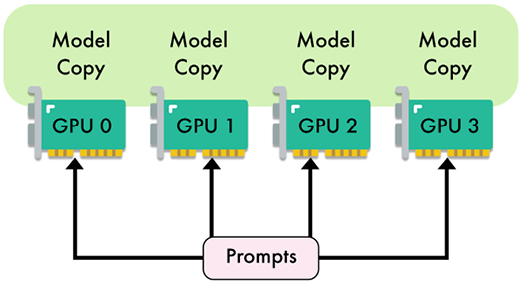
In data parallelism, the mini-batch is divided, and a copy of the model is available on each GPU. This speeds up model training by enabling multiple GPUs to work in parallel.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F65192617-e486-406c-a64f-a4990457e387_2034x1016.png)

#### **How It Works**
1. The same model is replicated across all the GPUs.
2. Each GPU is fed a different subset of the input data (a unique mini-batch).
3. All GPUs independently perform forward and backward passes, computing their own local gradients.
4. The gradients are collected and averaged across all GPUs.
5. The averaged gradients are used to update the model's parameters.

#### **Advantages**
- **Faster Training:** Each GPU processes a unique mini-batch concurrently, reducing overall training time.
- Particularly effective for large datasets.

#### **Limitations**
- **Memory Constraints:** Each GPU must store a complete copy of the model and its parameters.
- Unsuitable for training very large models (e.g., ViTs or LLMs) that exceed a single GPU's memory capacity.


-   Replicating the model on each GPU can be inefficient for very large models because of redundant memory usage.
-   Synchronization overhead can become a bottleneck as the number of GPUs increases.

---
## 3. Model Parallelism

When the model is too large for a single GPU, **model parallelism** comes into play by splitting the model across devices. There are several sub-types:

### A. Naïve (Vertical) Model Parallelism

-   **Description:** The model is split layer-by-layer (e.g., assigning the first half of layers to GPU 0 and the second half to GPU 1).
-   **Limitation:** It can lead to idle GPUs (pipeline “bubbles”) due to sequential dependencies.

### B. Pipeline Parallelism

-   **Description:** The model’s layers are partitioned among GPUs, and the input batch is split into micro-batches. Each GPU processes a different micro-batch concurrently, and intermediate outputs (activations) are passed along the pipeline.
-   **Benefits:** Reduces idle time by overlapping computation and communication.

### **Tensor Parallelism**
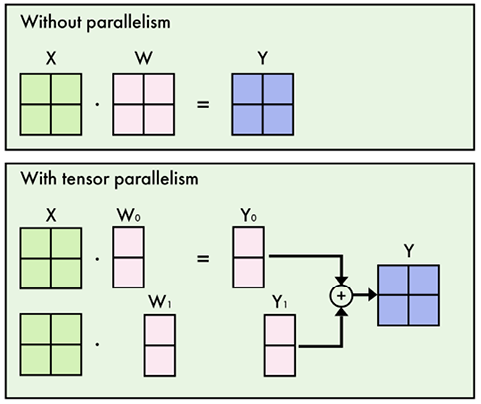
Unlike data parallelism, which divides the mini-batch across GPUs, tensor parallelism splits the **model itself** across multiple GPUs. This approach allows training of models that are too large to fit on a single GPU.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Ff3f25e94-a68b-4adb-9241-01489d5c633b_1772x1002.png)
#### **How It Works**
- Tensor parallelism divides model operations (e.g., matrix multiplication) across GPUs.
- Example: For matrix multiplication, GPUs can divide the matrix by **rows** or **columns**:
  - Each GPU processes a smaller chunk of the operation.
  - The results are concatenated to reconstruct the original output.
- Effectively, this approach distributes both computation and memory load across GPUs.
![](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F87d0967d-5661-4813-919d-de3531cdcda3_2154x1146.png)
---

### **Comparison: Data Parallelism vs. Tensor Parallelism**

| **Aspect**                | **Data Parallelism**                                              | **Tensor Parallelism**                      |
|---------------------------|-------------------------------------------------------------------|--------------------------------------------|
| **Data Handling**          | Mini-batch divided across GPUs                                   | Model divided across GPUs                  |
| **Model on GPUs**          | Entire model replicated on each GPU                             | Model split into smaller shards            |
| **Memory Requirements**    | Requires each GPU to store the entire model and its parameters   | Reduces memory requirements per GPU        |
| **Use Case**               | Suitable for medium-sized models                                | Essential for very large models (e.g., LLMs) |

Tensor parallelism is especially valuable for modern models like Vision Transformers (ViTs) and Large Language Models (LLMs), which exceed the memory limits of a single GPU.

Here's an updated table with the trade-offs each approach resolves, and which method addresses them:

| **Approach**          | **Advantages**                                                                 | **Disadvantages**                                                   | **Trade-off Solved**                                  | **Ideal Scenario**                                               |
|------------------------|-------------------------------------------------------------------------------|----------------------------------------------------------------------|-------------------------------------------------------|-------------------------------------------------------------------|
| **Data Parallelism**   | - Simplifies implementation. <br> - Good for scaling across GPUs.             | - Increased memory usage. <br> - Redundant memory consumption.       | Resolves communication bottleneck in model updates.   | When dataset size is the limiting factor.                        |
| **Tensor Parallelism** | - Low latency. <br> - Efficient GPU memory usage.                            | - Increased communication overhead among GPUs.                       | Balances computational load between GPUs.             | When low latency is more important than memory efficiency.        |
| **Pipeline Parallelism**| - Reduces memory consumption the most.                                       | - Pipeline bubbles lead to reduced efficiency.                       | Addresses GPU memory constraints.                     | When fitting the model within GPU memory is the primary concern. |

By combining these techniques, practitioners can strategically mitigate issues and optimize the model's performance according to hardware and application needs. Let me know if you'd like additional refinements!

## 4. Asynchronous Synchronization

In contrast to the strict synchronization in data parallelism, **asynchronous synchronization** allows GPUs to perform computations without waiting for gradient aggregation at every step.

-   **Pros:** Overlapping communication with computation can reduce overall training time.
-   **Cons:** Risks using stale gradients, which may harm convergence if not carefully tuned.

----------

## 5. Hybrid Parallelism

**Hybrid Parallelism** combines the strengths of different approaches to maximize hardware utilization. For example, a training setup might use:

-   **Data Parallelism** across nodes to split the dataset.
-   **Pipeline Parallelism** to divide model layers among GPUs.
-   **Tensor Parallelism or FSDP** within each node to split or shard large tensors.

This multi-dimensional approach (sometimes called 3D parallelism) allows training extremely large models efficiently.

----------

## 6. Latest Research Example: mLoRA

A recent paper that exemplifies advanced parallelism in fine-tuning is:  
**"mLoRA: Fine-Tuning LoRA Adapters via Highly-Efficient Pipeline Parallelism in Multiple GPUs"**  
_(Published December 2023)_

[arxiv.org](https://arxiv.org/abs/2312.02515)

### Key Contributions of mLoRA:

-   **LoRA-aware Pipeline Parallelism:** mLoRA introduces a specialized scheme that pipelines independent LoRA adapters across GPUs, greatly reducing communication overhead.
-   **Efficient Operator:** A new operator enhances GPU utilization during pipelined LoRA training.
-   **Improved Fine-Tuning Efficiency:** The paper demonstrates a reduction in fine-tuning task completion time by about 30% compared to state-of-the-art methods like FSDP.
-   **Scalability:** mLoRA enables simultaneous fine-tuning of larger models (e.g., two Llama-2-13B models) on a modest number of high-end GPUs (four NVIDIA RTX A6000 48GB GPUs), which would otherwise be infeasible with conventional methods.

## **Fully Sharded Data Parallelism (FSDP) – A Comprehensive Explanation**

## **🔹 Introduction**

Training large neural networks, especially **Large Language Models (LLMs)** like GPT or BERT, requires **massive GPU memory** and compute power. **Fully Sharded Data Parallelism (FSDP)** is an advanced **distributed training technique** that enables training models **larger than a single GPU's memory** by **splitting the model’s parameters across multiple GPUs** efficiently.

Let's consider a scenario with `n` GPUs and a model size denoted as `S`, in which the model cannot fit on one GPU but can fit on all the GPUs combined. After splitting the model “vertically,” each GPU has a slice of the model of size `S/n`. The time it takes for a single GPU to run the forward pass on its model slice is represented as `T_forward`, and the backward run time is denoted as `T_backward`.

# **🔹 Why is FSDP Needed?**

When training deep learning models, **memory limitations** are a major challenge. Here’s why:

### **1️⃣ Single GPU Memory Limitations**

-   GPUs have **fixed memory sizes** (e.g., 24GB for an NVIDIA RTX 4090).
-   Large models like GPT-3 require **hundreds of gigabytes of memory**.
-   A **single GPU** cannot handle such large models.

### **2️⃣ Traditional Model Parallelism is Inefficient**

One **naive approach** is to **split the model vertically** (pipeline parallelism):

**Example:**

-   Suppose a model has **9 layers**.
-   With **3 GPUs**, we assign:
    -   **GPU 1 → Layers 1-3**
    -   **GPU 2 → Layers 4-6**
    -   **GPU 3 → Layers 7-9**

**⚠️ Problem: Idle GPUs**
- The issue emerges when the first GPU completes its forward pass and intends to run forward pass on the next batch.  **We cannot begin the next forward pass for the subsequent batches before updating the initial weights**  of the first GPU model weights—` so the first GPU must wait for all downstream GPUs to complete the forward pass and propagate their respective gradients backwards before its weights can be updated, resulting in significant idle time. Specifically, the first GPU waits for  ` `*T_forward*(n-1) + T_backward*(n-1)*`  before applying backward propagation for the first batch.
-   The first GPU **must wait** for the last GPU to complete the forward pass before updating its weights.
-   If **T_forward** is the time for a forward pass, the total delay is:  $$ Tforward×(n−1)+Tbackward×(n−1)T_{forward} \times (n-1) + T_{backward} \times (n-1) $$
-   **Most of the GPUs remain idle for a long time**, reducing efficiency.
![](https://blog.clika.io/content/images/2024/01/image_1.svg)
### **✅ Solution: Fully Sharded Data Parallelism (FSDP)**

FSDP **eliminates idle time** and **reduces memory usage** by:

1.  **Splitting parameters across GPUs (sharding) instead of splitting layers.**
2.  **Sharing only required data** instead of duplicating entire models.
3.  **Ensuring all GPUs work in parallel** without long waiting times.

----------

# **🔹 Understanding FSDP: Key Concepts**

### **1️⃣ Vertical Splitting (Model Partitioning)**

-   Similar to pipeline parallelism, we **split the model into units** (groups of layers).
-   Each GPU is **responsible for certain layers**.
-   However, this is **not enough alone** to solve the memory issue.

### **2️⃣ Horizontal Splitting (Sharding)**

-   Instead of **storing entire layers**, each GPU **stores only a fraction of the model parameters**.
-   This process is called **sharding**.

**Example:**
> For example, in a model with 9 convolution layers, each unit is responsible for a specific range of layers. The first GPU unit might manage layers 1 to 3, the second unit, layers 4 to 6, and the last unit might oversee layers 7 to 9.
-   Suppose we have a model with **3 fully connected layers**.
-   Instead of storing **one full layer per GPU**, we store **one-third of each layer on each GPU**.
> Throughout the training process, `collaboration among GPUs occurs as they share necessary shards—in doing so, we store redundant parameters and incur communication overhead between the GPUs`, but in doing so, we’re able to keep all the GPUs busy at all times.
### **
3️⃣ Sharded Entities in PyTorch FSDP**

FSDP **shards (divides) three main components**:
## **FSDP (Fully Sharded Data Parallelism): Sharded Components**

FSDP shards (divides) three main components during training:
Under the `FULL_SHARD` strategy, the following key entities are subjected to sharding:
| **Sharded Entity**       | **Description**                  | **Why It Matters**                                                |
|---------------------------|----------------------------------|-------------------------------------------------------------------|
| **Model Parameters (MP)** | Weights, biases, and buffers     | Reduces memory usage by distributing them across GPUs             |
| **Gradients (GRD)**       | Computed during backpropagation  | Prevents memory bottlenecks in training                           |
| **Optimizer State (OS)**  | Stores Adam momentum, variance, etc. | Saves memory while preserving training accuracy                   |

For OS: Typically, the data are retained in 32-bit floating-point format (FP32), ensuring precision during the optimization process.

# **🔹 Step-by-Step Breakdown of FSDP**

Let’s assume we have **3 GPUs** and a model with **9 layers**. Each GPU is assigned **3 layers**.


-   **shard:**  a single chunk of the split entities  **that is attached to a specific GPU**  (contains a small portion of every entity across the entire model)
-   Activation (**ACT**): the activation calculated in each GPU separately during forward pass
-   **unit**: a part of the model with its assigned layers created by vertical model partition
-   `MEM_total`: the memory size of all the parameters to be stored, i.e.,  **MP + GRD + OS**
![](https://blog.clika.io/content/images/2024/01/Group-1631.svg)
## **🔹 Step 1: Setup**

1️⃣ **Dataset Split**

-   The dataset is **split into 3 parts**.
-   Each GPU handles a **separate batch**.

2️⃣ **Unit Assignment**

-   The model is divided into **units of layers**.
-   Example:
    -   **GPU 1 → Layers 1-3**
    -   **GPU 2 → Layers 4-6**
    -   **GPU 3 → Layers 7-9**

3️⃣ **Sharding the Model**

-   The parameters, optimizer states, and gradients are **sharded across GPUs**.
-   Each GPU **stores only 1/3 of the total memory** required.
- 
💡 As mentioned, the sharding of the model entities is 'horizontal,' meaning that each shard includes model parameters from every layer, as shown in the following diagram:
![](https://blog.clika.io/content/images/2024/01/Group-1669.svg)
----------

## **🔹 Step 2: Forward Pass**

💡 **Goal:** Compute activations for each batch in parallel across GPUs.

### **Forward Pass Steps:**

1️⃣ **Broadcast Model Parameters**

-   Each GPU **gathers the parameters** for **unit 1** (MP 1).
-   This allows all GPUs to perform the **forward pass in parallel**.
- -   _Broadcast model parameters:_  All GPUs will gather the model parameters of the first unit (MP 1) so they can run the first forward step.
![](https://blog.clika.io/content/images/2024/01/Group-1670.svg)

2️⃣ **Compute Forward Pass on Unit 1**

-   Each GPU will run forward pass on unit 1 on its respective batch using the complete MP 1 that each GPU gathered from all the other GPUs
-   Since each GPU has **different input batches**, they compute different activations.
![](https://blog.clika.io/content/images/2024/01/Group-1671.svg)
3️⃣ **Store Activations (ACT)**

-   Each GPU **saves its activations** for later use in backpropagation.

4️⃣ **Reshard MP 1 (Free Memory)**

-   MP 1 is **deleted** (except the portion owned by each GPU).
![](https://blog.clika.io/content/images/2024/01/Group-1672.svg)
5️⃣ **Repeat for Units 2 and 3**

-   The same steps are **repeated for MP 2 and MP 3**.
-
![](https://blog.clika.io/content/images/2024/01/Group-1673.svg)
6️⃣ **Compute Loss**

-   Each GPU computes **loss** for its respective batch.

----------

## **🔹 Step 3: Backward Pass**

💡 **Goal:** Compute gradients (GRD) and update model parameters.

### **Backward Pass Steps:**

1️⃣ **Broadcast Model Parameters for Unit 3**

-   MP 3 is **already available** from the forward pass.
-  Therefore this step can be skipped for the unit 3 but is required for the backward pass of unit 2 and 1.

2️⃣ **Compute Backward Pass for Unit 3**

-  Initiate backward propagation and update GRD using the ACT and MP on all GPUs for unit 3
![](https://blog.clika.io/content/images/2024/01/Group-1675.svg)
3️⃣ **Accumulate Gradients (Reduce-Scatter)**

-   All GPUs **sum the computed gradients** and distribute them evenly.
- Take the GRD calculated in each GPU for unit 3, sum them to get the accumulated GRD, then distribute the accumulated GRD across the GPUs.
![](https://blog.clika.io/content/images/2024/01/Group-1679-1.svg)
4️⃣ **Reshard MP 3 and ACT (Free Memory)**

-   The memory used for MP 3 and ACT is **freed**.
![](https://blog.clika.io/content/images/2024/01/Group-1680-1.svg)

5️⃣ **Repeat for Units 2 and 1**

-   The process is repeated **for all other units**.
- ![](https://blog.clika.io/content/images/2024/01/Group-1681-1.svg)


## **🔹 Step 4: Optimizer Step**

1️⃣ **Update Model Parameters**

-   The optimizer updates **weights and optimizer states**.
- ![](https://blog.clika.io/content/images/2024/01/Group-1682.svg)

2️⃣ **Next Batch**

-   The process repeats **for the next batch** until training is complete.

----------

# **🔹 Benefits of FSDP**

**Benefit**

**Why It’s Important**

✅ **Efficient GPU Usage**

All GPUs work **simultaneously** instead of waiting.

✅ **Lower Memory Requirements**

Each GPU holds only a **fraction** of the model.

✅ **Scalable for Large Models**

Works well for models **too large for a single GPU**.

✅ **Optimized Communication**

Uses **reduce-scatter** and **broadcast** to minimize overhead.

## **Important Functionalities of FSDP**

FSDP (Fully Sharded Data Parallelism) provides several key mechanisms to optimize the distributed training of large models. Here’s a detailed explanation and breakdown of each functionality:

---

### 1. Wrapping Policy

**Purpose:**  
To ensure FSDP uses memory efficiently by controlling how model layers are grouped into separate FSDP units.

**How It Works:**  
- **Without Wrapping:**  
  If a model (e.g., one with 100 layers) is not wrapped, all 100 layers are managed by a single FSDP unit. When gathering sharded parameters, the entire set of parameters for all 100 layers must be synchronized—no GPU memory is saved.
  
- **With Wrapping:**  
  By applying a wrapping policy, you can set conditions (for instance, wrapping every 20 layers) to seal the current FSDP unit and start a new one. This means that only a subset of layers is handled at a time, saving GPU memory.
  
**Important Note:**  
Focus on wrapping layers that include multi-attention and feedforward components, as these are the most memory intensive during training.

---

### 2. MixedPrecision Policy

**Purpose:**  
To offer flexibility in numerical precision for gradients and buffers, thereby optimizing both memory usage and training performance.

**Key Details:**  
- **Precision Options:**  
  - It is recommended to use **bfloat16** for gradients and buffers since FP16 requires additional rescaling (and if not done precisely, it can degrade performance).
  - FSDP supports using different precisions for different variables, e.g., gradients on bf16 while buffers on fp16.

- **Default Behaviors:**  
  - **BatchNorm Layers:** Automatically kept in FP32 for maintaining numerical stability. (This overrides any buffer precision setting.)
  - **Local Gradients:** Always computed in FP32 during backpropagation.
  - **Model Saving:** Models are saved in FP32 format to maximize portability, regardless of training precision.

---

### 3. Backward Prefetch

**Purpose:**  
To reduce training delays by overlapping communication with computation.

**How It Works:**  
- **Timing Control:**  
  By setting the system to `BACKWARD_PRE`, FSDP can begin requesting parameters for the next unit before the current unit’s computation is fully finished.
  
- **Benefit:**  
  This overlapping of the all-gather communication (to fetch parameters) with the gradient computation on the current unit reduces overall communication overhead and speeds up training.  
- **Trade-Off:**  
  It may use slightly more memory due to early parameter prefetching.

---

### 4. CPU Offloading

**Purpose:**  
To enable training of models that are too large to fully reside in GPU memory even with sharding.

**How It Works:**  
- **Offloading Strategy:**  
  When GPU memory is insufficient, parameters and gradients that exceed GPU capacity are offloaded to the CPU.
  
- **Key Considerations:**  
  - **Implicit Gradient Offloading:** Gradients are offloaded along with parameters to ensure they reside on the same device, a requirement for optimizer operations.
  - **Performance Impact:**  
    Frequent transfers between CPU and GPU can slow down training, but this trade-off allows for training larger-scale models that otherwise would be impossible.

---

### 5. Activation Checkpointing

**Purpose:**  
To reduce memory consumption during training at the cost of some recomputation during the backward pass.

**How It Works:**  
- **Selective Checkpointing:**  
  Common practice involves checkpointing each transformer block. Only a subset of activations is stored, and the rest is recomputed during backpropagation.
  
- **Impact:**  
  - For very large models (e.g., 13B parameters), this can increase throughput (reported increases around 10%).
  - For smaller models (e.g., 7B parameters), activation checkpointing may not be necessary.

---

### 6. Sharding Strategies

**Purpose:**  
To provide flexible options for splitting model components (parameters, optimizer states, gradients) across available GPUs.

**Available Strategies:**  

| **Sharding Strategy**        | **Description**                                                                                     |
|------------------------------|-----------------------------------------------------------------------------------------------------|
| **FULL_SHARD (default)**     | Shards all model components—parameters, optimizer states, and gradients—across GPUs.                 |
| **SHARD_GRAD_OP**            | Keeps model parameters intact during the forward pass; helps reduce communication overhead.          |
| **NO_SHARD**                 | Similar to traditional DDP where each GPU stores a full replica of the model.                      |
| **HYBRID_SHARD**             | Uses FULL_SHARD within individual nodes and NO_SHARD across nodes, balancing between efficiency and ease-of-use. |

---

### 7. Checkpointing Type

**Purpose:**  
To allow seamless resumption of training and to facilitate model deployment by saving state efficiently.

**Options:**  

- **FULL_STATE_DICT:**  
  - **Process:**  
    All parameters, optimizer states, and gradients are gathered to rank 0 (using its CPU memory) and then saved.
  - **Limitation:**  
    The maximum model size that can be saved is bounded by available CPU memory. Resuming training requires scattering these parameters back to other ranks.

- **SHARDED_STATE_DICT:**  
  - **Process:**  
    Each GPU (rank) saves its own parameters, optimizer states, and gradients independently.
  - **Advantage:**  
    This removes the CPU memory limitation and is often better suited for very large models.

---

## **Summary**

FSDP enhances large-scale model training through:

- **Wrapping Policy:** Efficiently groups layers to minimize per-unit memory demand.
- **MixedPrecision Policy:** Customizes numerical precision to strike a balance between speed and accuracy.
- **Backward Prefetch:** Overlaps communication with computation, reducing delays.
- **CPU Offloading:** Allows training of models too large to fit solely in GPU memory.
- **Activation Checkpointing:** Lowers memory usage by re-computing activations while slightly increasing compute load.
- **Sharding Strategies:** Offers multiple methods to partition model components best suited for your hardware and model size.
- **Checkpointing Types:** Provides versatile saving and resuming techniques to ensure training can be continued reliably.

Each of these functionalities works together to overcome the memory and computational limitations inherent in training very large models, making FSDP a robust solution for distributed deep learning.


 🚀

### Learning Rate:


Training large language models (LLMs) effectively requires strategies to stabilize and optimize the learning process. Three such techniques are **learning rate warmup**, **cosine decay**, and **gradient clipping**. Each plays a crucial role in enhancing model performance and training stability.

**1. Learning Rate Warmup**

`Learning rate warmup involves gradually increasing the learning rate from a low initial value to a predetermined peak value over a set number of steps at the beginning of training.`  
> This approach helps prevent large, destabilizing updates early in training, allowing the model to adjust smoothly.

_Implementation Example:_

Suppose we plan to train an LLM for 15 epochs, starting with an initial learning rate of 0.0001 and increasing it to a peak learning rate of 0.01. If the total number of training steps is 135, setting the warmup phase to 20% of the total steps results in 27 warmup steps.

The number of warmup steps is usually set between 0.1% and 20% of the total number of steps, which we can calculate as follows:
```python
import torch

n_epochs = 15
initial_lr = 0.0001
peak_lr = 0.01
total_steps = len(train_loader) * n_epochs
warmup_steps = int(0.2 * total_steps)

optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)

lr_increment = (peak_lr - initial_lr) / warmup_steps

global_step = -1
track_lrs = []

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr

        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(lr)

```


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/D-1.png)

**2. Cosine Decay**

After the warmup phase, `applying a cosine decay to the learning rate can further enhance training by gradually reducing the learning rate following a half-cosine cycle`.

```python
import math

min_lr = 0.1 * initial_lr
track_lrs = []
global_step = -1

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1

        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(lr)

```

>  This gradual reduction helps the model converge more smoothly and avoid overshooting minima.during the training process,


![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/D-2.png)


**3. Gradient Clipping**

Gradient clipping is a technique used to prevent exploding gradients by capping the gradients during backpropagation to a predefined threshold. This ensures that the updates to the model's parameters remain within a manageable range, contributing to training stability.

`Here, the term “norm” signifies the measure of the gradient vector’s length, or magnitude, within the model’s parameter space`, specifically referring to the L2 norm, also known as the Euclidean norm.

In mathematical terms, for a vector  **_v_**  composed of components  **_v_**  = [_v_1,  _v_2, ...,  _v__n_], the L2 norm is

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-1.png)

This calculation method is also applied to matrices. For instance, consider a gradient matrix given by

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-2.png)

If we want to clip these gradients to a  `max_norm`  of 1, we first compute the L2 norm of these gradients, which is

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-3.png)

Given that |**G**|2  = 5 exceeds our  `max_norm`  of 1, we scale down the gradients to ensure their norm equals exactly 1. This is achieved through a scaling factor, calculated as  `max_norm`/|**G**|2  = 1/5. Consequently, the adjusted gradient matrix  **G'**  becomes

![figure](https://learning.oreilly.com/api/v2/epubs/urn:orm:book:9781633437166/files/Images/Equation-eqs-D-4.png)

After computing the gradients via backpropagation, gradient clipping can be applied as follows:

```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()

```

In this snippet, gradients are clipped to a maximum L2 norm of 1.0 before the optimizer updates the model parameters.

**4. Integrating the Techniques**

Combining learning rate warmup, cosine decay, and gradient clipping can lead to more stable and efficient training of LLMs. The following function integrates these techniques into a training loop:

```python
import tiktoken

def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-5, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    peak_lr = optimizer.param_groups[0]["lr"]
    total_steps = len(train_loader) * n_epochs
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            if global_step < warmup_steps:
                lr = initial_lr + global_step * lr_increment
            else:
                progress = (global_step - warmup_steps) / (total_steps - warmup_steps)
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)

            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            if global_step >= warmup_steps:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
 

```